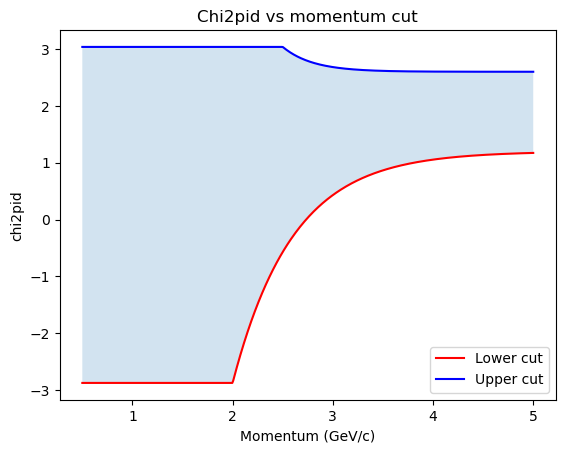

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

# ---------------------------------------------------------------------------
# K+ pass-2 chi2pid parameters (pid_cuts.java lines 438–439)
# ---------------------------------------------------------------------------
MU_KPLUS = 0.082
SIGMA_KPLUS = 0.985

# Lower-bound exponential parameters for p > 2 GeV/c (pid_cuts.java line 443)
LOWER_C = 1.2        # plateau value the exponential decays away from
LOWER_P0 = 2.0       # momentum at which the exponential kicks in
LOWER_TAU = 0.6      # decay constant in GeV/c

# Upper-bound exponential parameters for p > 2.5 GeV/c (pid_cuts.java line 445)
UPPER_C = 2.6        # plateau value the exponential decays away from
UPPER_P0 = 2.5       # momentum at which the upper bound starts contracting
UPPER_TAU = 0.3      # decay constant in GeV/c

# ---------------------------------------------------------------------------
# π+ pass-2 chi2pid parameters (pid_cuts.java lines 428–429)
# ---------------------------------------------------------------------------
MU_PIPLUS = -0.067
SIGMA_PIPLUS = 0.956

# Upper-bound exponential parameters for π+ at p > 3.5 GeV (pid_cuts.java line 433)
# Lower bound stays flat at μ−3σ for all p (no lower-bound exponential for π+)
PIPLUS_UPPER_C = -0.55
PIPLUS_UPPER_P0 = 3.5
PIPLUS_UPPER_TAU = 0.55

def _const_plus_exponential(c: float, a: float, tau: float,
                             p0: float, p: np.ndarray) -> np.ndarray:
    """
    Evaluate the helper function used by pid_cuts.java (line 263–264).

        f(p) = c + a * exp( -(p - p0) / tau )

    Parameters
    ----------
    c   : asymptotic plateau (value as p → ∞)
    a   : amplitude of the exponential term at p = p0
    tau : decay constant (GeV/c); controls how quickly the exponential falls
    p0  : reference momentum (GeV/c) at which the exponential term equals *a*
    p   : track momentum array (GeV/c)

    Returns
    -------
    np.ndarray, same shape as *p*
    """
    return c + a * np.exp(-(p - p0) / tau)

p_vals = np.linspace(0.5, 5, 500)

chi2_lower = np.where(
    p_vals < 2.0,
    MU_KPLUS - 3.0 * SIGMA_KPLUS,
    _const_plus_exponential(
        LOWER_C,
        (MU_KPLUS - 3.0 * SIGMA_KPLUS) - LOWER_C,
        LOWER_TAU,
        LOWER_P0,
        p_vals
    )
)

chi2_upper = np.where(
    p_vals < 2.5,
    MU_KPLUS + 3.0 * SIGMA_KPLUS,
    _const_plus_exponential(
        UPPER_C,
        (MU_KPLUS + 3.0 * SIGMA_KPLUS) - UPPER_C,
        UPPER_TAU,
        UPPER_P0,
        p_vals
    )
)

fig, ax = plt.subplots()

ax.plot(p_vals, chi2_lower, label="Lower cut", color="red")
ax.plot(p_vals, chi2_upper, label="Upper cut", color="blue")

ax.fill_between(p_vals, chi2_lower, chi2_upper, alpha=0.2)

ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("chi2pid")
ax.set_title("Chi2pid vs momentum cut")

ax.legend()

plt.show()